In [285]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "Thinned_Rescomp", "utils")))
import ResComp
from helper import get_orbit, create_network
from metrics import vpt_time
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp
from scipy import optimize

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif",
    'font.sans-serif': ['Computer Modern Roman'],
    'font.serif': ['Computer Modern Roman'],
    'font.size': 16
})

In [286]:
n = 50
network_type = "directed_erdos"
rho = 2
mean_degree = 5
p = mean_degree / n
alpha = 2e-08
gamma = 10
sigma = 0.014
tol = 5.

t_train, U_train, t_test, U_test = get_orbit(duration=4, system='lorenz', switch=3)
A = create_network([n,p], network_type, rho)

In [287]:
res = ResComp.ResComp(A, res_sz=n, mean_degree=mean_degree, 
                                ridge_alpha=alpha, spect_rad=rho, sigma=sigma, 
                                gamma=gamma, map_initial='activ_f')

In [288]:
initial_conditions = np.random.uniform(-1.,1.,n)
states_train = res.internal_state_response(t_train, U_train, initial_conditions)
res.train(t_train, U_train)
U_pred, states_pred = res.predict(t_test, r0=res.r0, return_states=True)
vpt = vpt_time(t_test, U_test, U_pred, vpt_tol=tol)

In [289]:
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])

u_true = np.vstack((U_train, U_test))
u_hat = res.predict(t, r0=res.r0)

(401, 3)
(401, 3)


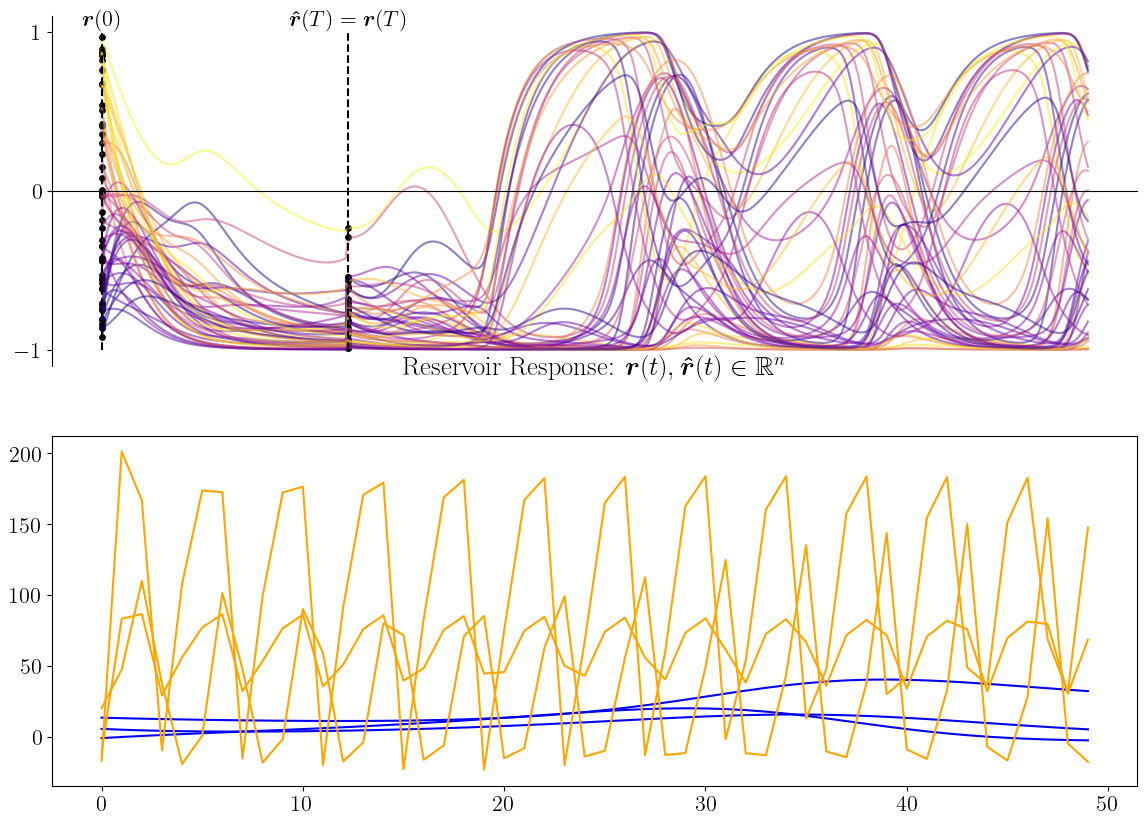

In [290]:
norm = Normalize(vmin=min(initial_conditions), vmax=max(initial_conditions))
cmap = plt.get_cmap('plasma')

fig, axes = plt.subplots(2, 1, figsize=(14,10))

ax1 = axes[0]
for r, r0 in zip(reservoir_states.T, initial_conditions):
    ax1.plot(t, r, color=cmap(norm(r0)), alpha=0.5)


ax1.vlines(x=0, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.zeros(50), reservoir_states[0], c="black", s=15)
ax1.annotate(
    r"$\bm{r}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.vlines(x=T, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.ones(50)*T, reservoir_states[T], c="black", s=15)
ax1.annotate(
    r"$\bm{\hat r}(T) = \bm{r}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.set_yticks([-1,0,1])
ax1.set_xticks([])

ax1.spines['bottom'].set_position(('data', 0))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title(r"Reservoir Response: $\bm{r}(t), \bm{\hat r}(t) \in \mathbb{R}^n$", y=-0.05)

ax2 = axes[1]

print(u_hat.shape)
print(u_true.shape)

for u in u_true.T:
    ax2.plot(t[:50], u[:50], color="blue")

for u in u_hat.T:
    ax2.plot(t[:50], u[:50], color="orange")

plt.show()